# Predicting Diabetes Using Machine Learning

This notebook builds a reproducible diabetes prediction workflow using a Kaggle healthcare diabetes dataset. It inspects the data, visualizes feature relationships, trains classification models, and compares model performance.

## Context & Methods

Dataset source: https://www.kaggle.com/datasets/ehababoelnaga/diabetes-dataset

The target variable is `Outcome`, where `1` indicates diabetes and `0` indicates no diabetes. The workflow uses an 80/20 stratified train-test split with `random_state=100` for reproducibility.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

mkdir -p failed for path C:\Users\walte\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\walte\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\walte\AppData\Local\Temp\matplotlib-7x_xsrve because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Load Dataset

In [2]:
file_path = "Healthcare-Diabetes.csv"
df = pd.read_csv(file_path)
df.head()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1


## Data Inspection

In [3]:
print("Dataset shape:")
print(df.shape)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nClass distribution:")
print(df["Outcome"].value_counts())

Dataset shape:
(2768, 10)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        2768 non-null   int64  
 1   Pregnancies               2768 non-null   int64  
 2   Glucose                   2768 non-null   int64  
 3   BloodPressure             2768 non-null   int64  
 4   SkinThickness             2768 non-null   int64  
 5   Insulin                   2768 non-null   int64  
 6   BMI                       2768 non-null   float64
 7   DiabetesPedigreeFunction  2768 non-null   float64
 8   Age                       2768 non-null   int64  
 9   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 216.4 KB
None

Missing values:
Id                          0
Pregnancies                 0
Glucose                     0
BloodPressure               0
Sk

## Descriptive Statistics

In [4]:
df.describe()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000
mean,1384.500000,3.742775,121.102601,69.134393,20.824422,80.127890,32.137392,0.471193,33.132225,0.343931
std,799.197097,3.323801,32.036508,19.231438,16.059596,112.301933,8.076127,0.325669,11.777230,0.475104
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,692.750000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,1384.500000,3.000000,117.000000,72.000000,23.000000,37.000000,32.200000,0.375000,29.000000,0.000000
75%,2076.250000,6.000000,141.000000,80.000000,32.000000,130.000000,36.625000,0.624000,40.000000,1.000000
max,2768.000000,17.000000,199.000000,122.000000,110.000000,846.000000,80.600000,2.420000,81.000000,1.000000


## Correlation Heatmap

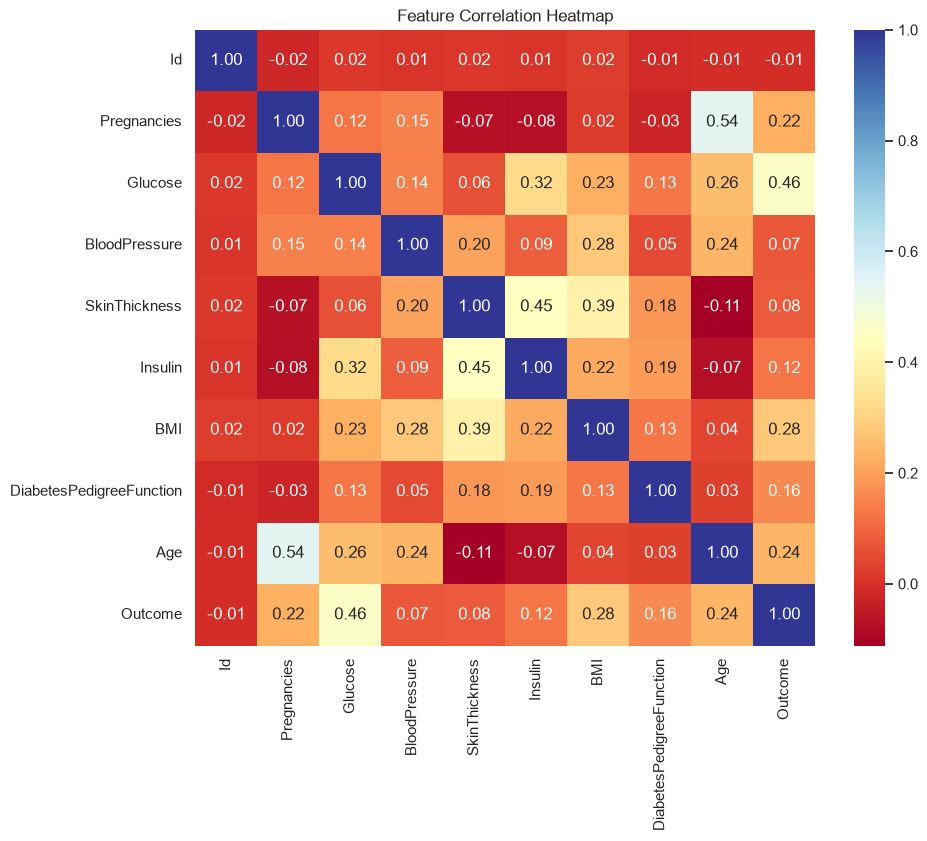

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="RdYlBu", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

## Split Features And Target

In [6]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=100,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2214, 9)
X_test: (554, 9)
y_train: (2214,)
y_test: (554,)


## Random Forest Model

In [7]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=100
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

## Random Forest Evaluation

In [8]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest Results")
print("Accuracy:", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall:", round(rf_recall, 3))
print("F1 Score:", round(rf_f1, 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Results
Accuracy: 0.987
Precision: 0.989
Recall: 0.974
F1 Score: 0.982

Confusion Matrix:
[[361   2]
 [  5 186]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       363
           1       0.99      0.97      0.98       191

    accuracy                           0.99       554
   macro avg       0.99      0.98      0.99       554
weighted avg       0.99      0.99      0.99       554



## Feature Importance

                    Feature  Importance
2                   Glucose    0.278853
6                       BMI    0.161053
8                       Age    0.136803
7  DiabetesPedigreeFunction    0.116467
3             BloodPressure    0.081706
1               Pregnancies    0.071808
5                   Insulin    0.063078
4             SkinThickness    0.059339
0                        Id    0.030894


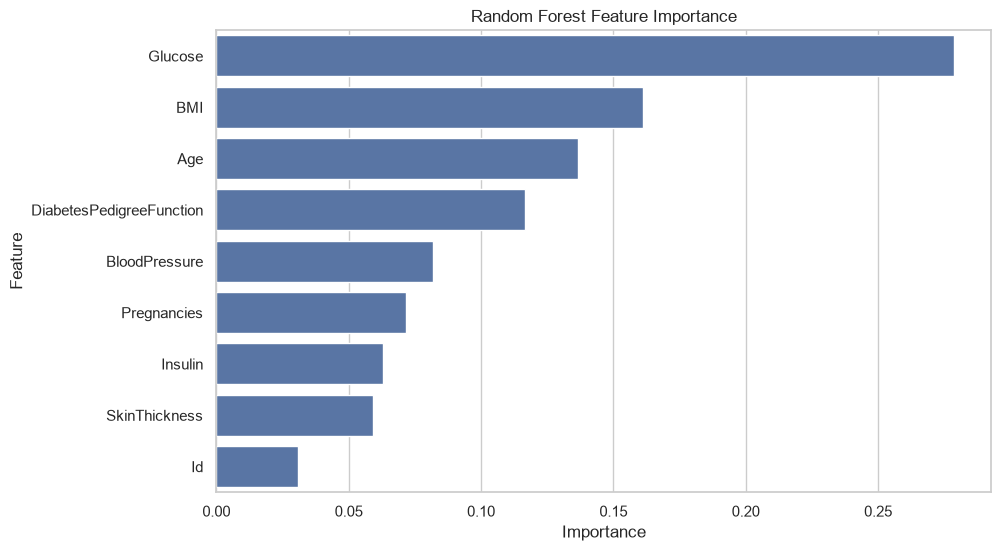

In [9]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()

## Cleaned Dataset

In [10]:
columns_to_drop = [
    "Id",
    "BloodPressure",
    "Pregnancies",
    "Insulin",
    "SkinThickness"
]

existing_columns_to_drop = [
    column for column in columns_to_drop
    if column in df.columns
]

cleaned_df = df.drop(columns=existing_columns_to_drop)

cleaned_df.head()

,Glucose,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,33.6,0.627,50,1
1,85,26.6,0.351,31,0
2,183,23.3,0.672,32,1
3,89,28.1,0.167,21,0
4,137,43.1,2.288,33,1


## Random Forest Using Cleaned Dataset

In [11]:
X_clean = cleaned_df.drop("Outcome", axis=1)
y_clean = cleaned_df["Outcome"]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=100,
    stratify=y_clean
)

clean_random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=100
)

clean_random_forest.fit(X_train_clean, y_train_clean)
clean_rf_predictions = clean_random_forest.predict(X_test_clean)

clean_rf_accuracy = accuracy_score(y_test_clean, clean_rf_predictions)
clean_rf_precision = precision_score(y_test_clean, clean_rf_predictions)
clean_rf_recall = recall_score(y_test_clean, clean_rf_predictions)
clean_rf_f1 = f1_score(y_test_clean, clean_rf_predictions)

print("Cleaned Random Forest Results")
print("Accuracy:", round(clean_rf_accuracy, 3))
print("Precision:", round(clean_rf_precision, 3))
print("Recall:", round(clean_rf_recall, 3))
print("F1 Score:", round(clean_rf_f1, 3))

Cleaned Random Forest Results
Accuracy: 0.986
Precision: 0.984
Recall: 0.974
F1 Score: 0.979


## Logistic Regression Model

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

logistic_regression = LogisticRegression(
    random_state=100,
    max_iter=1000
)

logistic_regression.fit(X_train_scaled, y_train_clean)
log_predictions = logistic_regression.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test_clean, log_predictions)
log_precision = precision_score(y_test_clean, log_predictions)
log_recall = recall_score(y_test_clean, log_predictions)
log_f1 = f1_score(y_test_clean, log_predictions)

print("Logistic Regression Results")
print("Accuracy:", round(log_accuracy, 3))
print("Precision:", round(log_precision, 3))
print("Recall:", round(log_recall, 3))
print("F1 Score:", round(log_f1, 3))

Logistic Regression Results
Accuracy: 0.745
Precision: 0.664
Recall: 0.529
F1 Score: 0.589


## Model Comparison

In [13]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Cleaned Random Forest",
        "Logistic Regression"
    ],
    "Accuracy": [
        rf_accuracy,
        clean_rf_accuracy,
        log_accuracy
    ],
    "Precision": [
        rf_precision,
        clean_rf_precision,
        log_precision
    ],
    "Recall": [
        rf_recall,
        clean_rf_recall,
        log_recall
    ],
    "F1 Score": [
        rf_f1,
        clean_rf_f1,
        log_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.987365,0.989362,0.973822,0.981530
1,Cleaned Random Forest,0.985560,0.984127,0.973822,0.978947
2,Logistic Regression,0.745487,0.664474,0.528796,0.588921


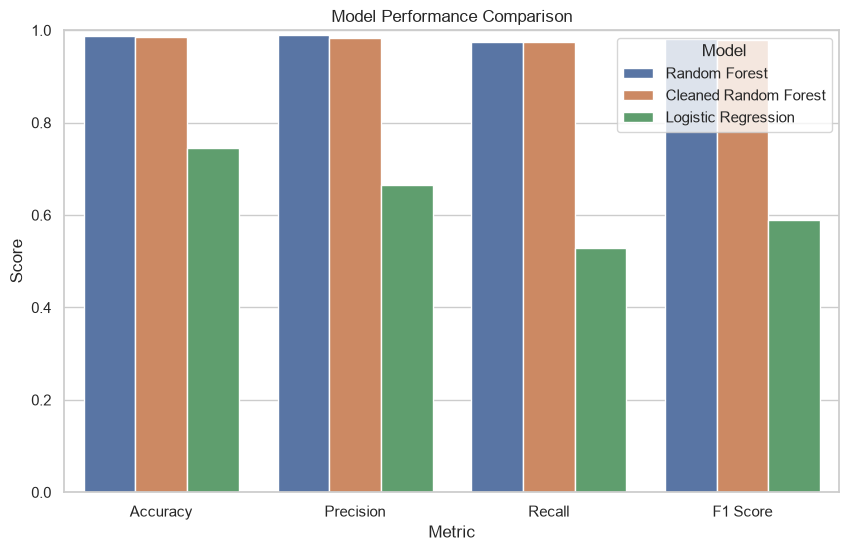

In [14]:
plt.figure(figsize=(10, 6))
results_melted = results.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.show()

## Takeaways

Run the notebook from top to bottom to review the executed metrics and compare which model performs best on the held-out test data.